In [1]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=0


In [2]:
import torch
import lightning.pytorch
from main import SatCLIPLightningModule
import location_encoder as LE
from temporal_encoding import Fourier, Direct
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

/home/leca5365/miniconda3/envs/satclip313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setting anomaly detection to True


In [3]:
# free CUDA memory
torch.cuda.empty_cache()

In [7]:
# Create a toy spatio-temporal encoder
temporal_enc = LE.get_temporal_encoding("fourier", k=10)
pos_enc = LE.get_positional_encoding("sphericalharmonics")
nnet = LE.get_neural_network("siren", input_dim=temporal_enc.embedding_dim + pos_enc.embedding_dim)
ste = LE.SpatioTemporalEncoder(pos_enc, temporal_enc, nnet)

x = torch.randn(5, 3)  # 5 locations with 3 coordinates (e.g., lat, lon, time)

y = ste(x)
y.shape

torch.Size([5, 256])

In [8]:
# Create a spatio-temporal encoder from a checkpoint
# ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-temporal-55k/satclip/checkpoints/best.ckpt'
ckpt_path = '/home/leca5365/Documents/satclip/satclip/satclip_temporal_logs/satclip-s2-temporal-55k/satclip-fixed-fourier/checkpoints/best.ckpt'
lightning_model = SatCLIPLightningModule.load_from_checkpoint(ckpt_path)
lightning_model.eval()
ste = lightning_model.model.location
visual_encoder = lightning_model.model.visual

x = torch.randn(5, 3, device="cuda:0").double()  # 5 locations with 3 coordinates (e.g., lat, lon, time)
ste(x).shape

using pretrained moco vit16


torch.Size([5, 256])

In [5]:
# Sample some embeddings
n_points = 100
times = np.linspace(0, 365, 12)
lats = np.linspace(-90, 90, 180)
lons = np.linspace(-180, 180, 360)
coords = np.stack(np.meshgrid(lons, lats, times), -1).reshape(-1, 3)
coords_tensor = torch.tensor(coords, device="cuda:0").double()
print(coords_tensor.shape)

embeddings_torch = ste(coords_tensor)
embeddings = embeddings_torch.cpu().detach().numpy()

torch.Size([777600, 3])


In [6]:
# Create land-mask
m = Basemap(projection='cyl', resolution='c')
xs, ys = m(coords[:, 0], coords[:, 1])
land_mask = np.array([m.is_land(xi, yi) for xi, yi in zip(xs, ys)])
land_coords = coords[land_mask]

In [9]:
# Select an anchor point in space-time (Mt Elbert, CO at time 0)
anchor_point = np.array([[-106.4454, 39.1178, 0]])  # Mount Elbert, CO at time 0
anchor_tensor = torch.tensor(anchor_point, device="cuda:0").double()
anchor_embedding_torch = ste(anchor_tensor)
anchor_name = "mt_elbert"

In [20]:
# Select an anchor point in space-time (Mt Elbert, CO at time 180)
anchor_point = np.array([[-106.4454, 39.1178, 180]])  # Mount Elbert, CO at dat 180
anchor_tensor = torch.tensor(anchor_point, device="cuda:0").double()
anchor_embedding_torch = ste(anchor_tensor)
anchor_name = "mt_elbert"

In [22]:
# Select an anchor point in space-time (Congo Basin at time 0)
anchor_point = np.array([[20.0, 0.0, 0]])  # Congo Basin at time 0
anchor_tensor = torch.tensor(anchor_point, device="cuda:0").double()
anchor_embedding_torch = ste(anchor_tensor)
anchor_name = "congo_basin"

In [24]:
# Select an anchor point in space-time (Congo Basin at time 180)
anchor_point = np.array([[20.0, 0.0, 180]])  # Congo Basin at time 180
anchor_tensor = torch.tensor(anchor_point, device="cuda:0").double()
anchor_embedding_torch = ste(anchor_tensor)
anchor_name = "congo_basin"

In [15]:
# Select an anchor point in space-time (African tropic capricornish at time 0)
anchor_point = np.array([[20.0, -20.0, 0]])  # African tropic capricornish at time 0
anchor_tensor = torch.tensor(anchor_point, device="cuda:0").double()
anchor_embedding_torch = ste(anchor_tensor)
anchor_name = "african_tropic_capricornish"

In [25]:
# Compute the cosine similarity between all embeddings and the anchor embedding
csim = torch.nn.functional.cosine_similarity(embeddings_torch, anchor_embedding_torch)
csim_np = csim.cpu().detach().numpy()
land_csim = csim_np[land_mask]
print(land_csim.shape)
print(land_csim.min(), land_csim.max())

# Plot the results
from PIL import Image
import io
frames = []
time_window = 15

for doy in np.unique(land_coords[:,2]):
    fig, ax = plt.subplots(1,1, figsize=(20, 10))
    m = Basemap(projection='cyl', resolution='c', ax=ax)
    m.drawcoastlines()

    # Land mask
    t_land_idx = np.abs(land_coords[:, 2] - doy) < time_window  # Within 10 days of doy
    t_land_coords = land_coords[t_land_idx]
    t_land_csim = land_csim[t_land_idx]
    print(t_land_coords.shape)

    # ax.scatter(t_land_coords[:, 0], t_land_coords[:, 1], s=10, c=t_land_csim, label="Location")
    ax.scatter(t_land_coords[:, 0], t_land_coords[:, 1], s=10, c=t_land_csim, cmap='coolwarm', vmax=1.0, vmin=-1.0, label="Location")
    ax.scatter(anchor_point[0,0], anchor_point[0,1], s=200, c='white', marker='*', edgecolors='black', label="Anchor Point")
    ax.text(anchor_point[0,0]+2, anchor_point[0,1], f"t={anchor_point[0,2]}", color='white', fontsize=12, weight='bold')
    ax.set_title(f"Day of Year: {int(doy)}")
    # plt.savefig(f"land_pca_doy_{int(doy)}.png")
    # plt.show()
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))

    plt.close(fig)

frames[0].save(f'land_csim_{anchor_name}_day_{int(anchor_point[0,2])}_55k_frozenvit_evolution.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)
print("saved: ", f'land_csim_{anchor_name}_day_{int(anchor_point[0,2])}_55k_frozenvit_evolution.gif')

(178716,)
-0.5912868374513452 0.9983385503874282
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
saved:  land_csim_congo_basin_day_180_55k_frozenvit_evolution.gif


In [26]:
# PCA fit
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca_result = pca.fit_transform(embeddings)

# Convert PCA to 3-channel colors 
pca_result_min = pca_result.min(axis=0)
pca_result_max = pca_result.max(axis=0)
pca_normalized = (pca_result - pca_result_min) / (pca_result_max - pca_result_min)

# Land mask
m = Basemap(projection='cyl', resolution='c')
xs, ys = m(coords[:, 0], coords[:, 1])
land_mask = np.array([m.is_land(xi, yi) for xi, yi in zip(xs, ys)])
land_coords = coords[land_mask]
land_pca = pca_normalized[land_mask]

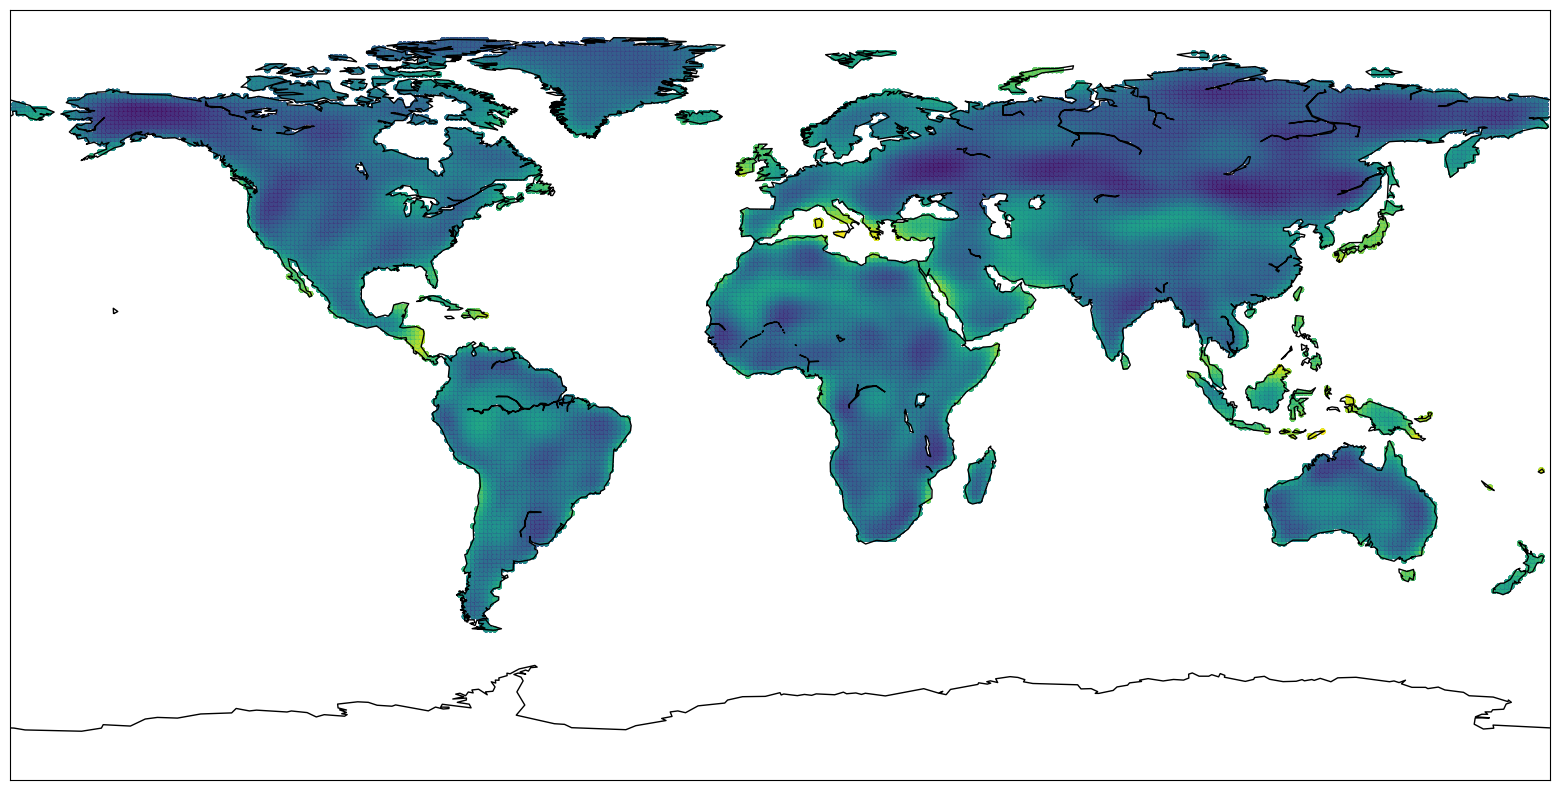

In [ ]:
# Visual PCA dimensions
fig, ax = plt.subplots(1,1, figsize=(20, 10))
m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()

ax.scatter(land_coords[:, 0], land_coords[:, 1], s=10, c=land_pca[:,0], cmap='viridis', label="Location")
plt.show()
plt.title('PCA-1')

In [18]:
np.unique(land_coords[:,2])

array([  0.        ,  33.18181818,  66.36363636,  99.54545455,
       132.72727273, 165.90909091, 199.09090909, 232.27272727,
       265.45454545, 298.63636364, 331.81818182, 365.        ])

(44679, 3)


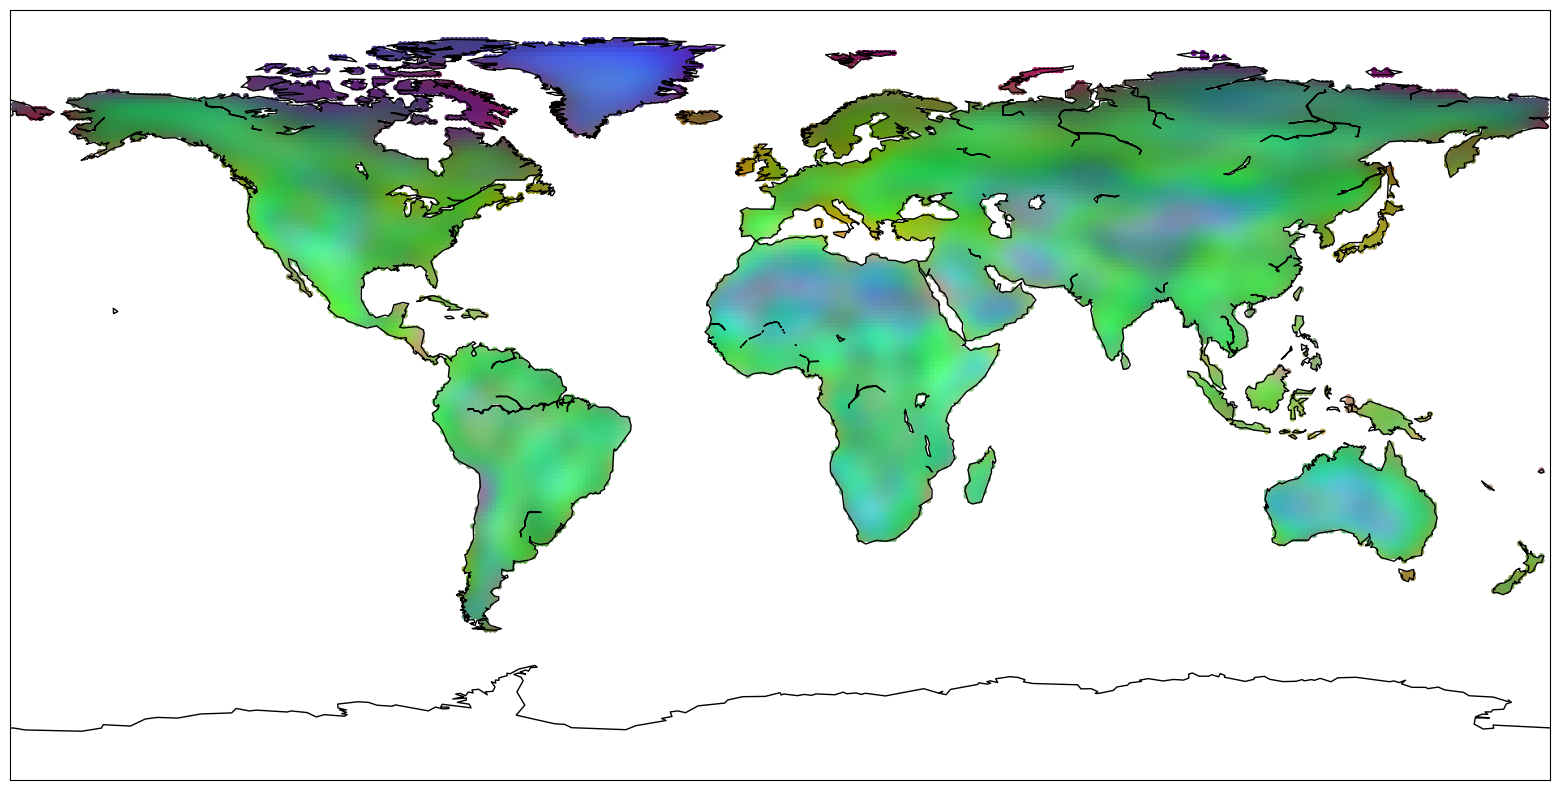

In [16]:
# Spring
fig, ax = plt.subplots(1,1, figsize=(20, 10))
m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()

# Land mask
t_land_idx = land_coords[:, 2] < 80  # Spring time
t_land_coords = land_coords[t_land_idx]
t_land_pca = land_pca[t_land_idx]
print(t_land_coords.shape)

ax.scatter(t_land_coords[:, 0], t_land_coords[:, 1], s=10, c=t_land_pca, label="Location")
plt.show()

(178716, 3)


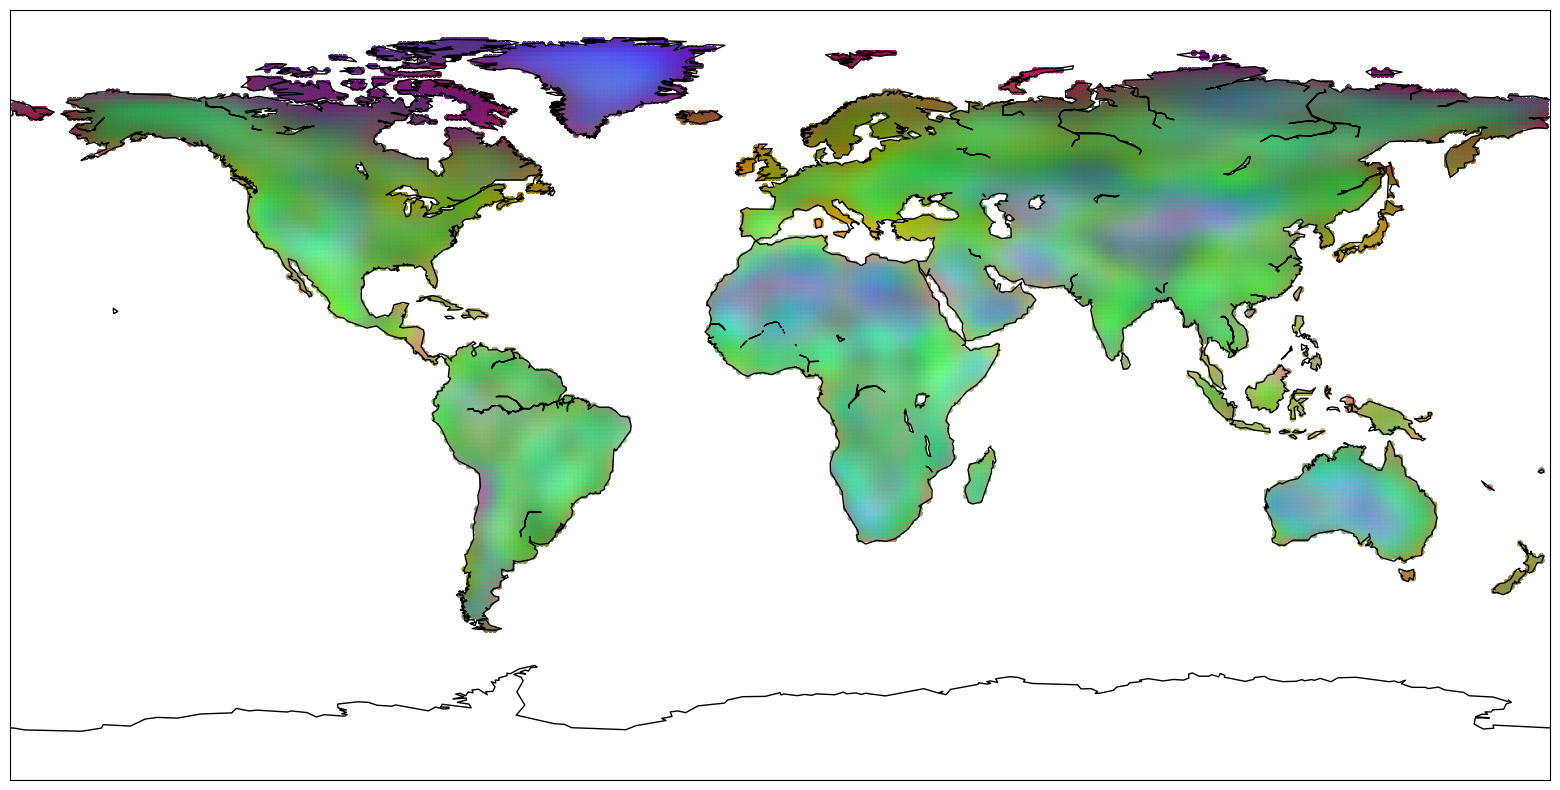

In [17]:
# Summer
fig, ax = plt.subplots(1,1, figsize=(20, 10))
m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()

# Land mask
t_land_idx = np.logical_or(land_coords[:, 2] > 80, land_coords[:, 2] < 170)  # Summer time
t_land_coords = land_coords[t_land_idx]
t_land_pca = land_pca[t_land_idx]
print(t_land_coords.shape)

ax.scatter(t_land_coords[:, 0], t_land_coords[:, 1], s=10, c=t_land_pca, label="Location")
plt.show()

In [29]:
# Evolution of PCA of embeddings over time
from PIL import Image
import io
frames = []

for doy in np.unique(land_coords[:,2]):
    fig, ax = plt.subplots(1,1, figsize=(20, 10))
    m = Basemap(projection='cyl', resolution='c', ax=ax)
    m.drawcoastlines()

    # Land mask
    t_land_idx = np.abs(land_coords[:, 2] - doy) < 30  # Within 10 days of doy
    t_land_coords = land_coords[t_land_idx]
    t_land_pca = land_pca[t_land_idx]
    print(t_land_coords.shape)

    # ax.scatter(t_land_coords[:, 0], t_land_coords[:, 1], s=10, c=t_land_pca, label="Location")
    ax.scatter(t_land_coords[:, 0], t_land_coords[:, 1], s=10, c=t_land_pca, cmap='viridis', label="Location")
    ax.set_title(f"Day of Year: {int(doy)}")
    # plt.savefig(f"land_pca_doy_{int(doy)}.png")
    # plt.show()
    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))

    plt.close(fig)

frames[0].save('land_pca3_55k_frozenvit_evolution.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)

(14893, 3)


/tmp/ipykernel_1805501/2547996384.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(t_land_coords[:, 0], t_land_coords[:, 1], s=10, c=t_land_pca, cmap='viridis', label="Location")


(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)
(14893, 3)


In [20]:
# t-SNE plots of spatio-temporal embeddings
from sklearn.manifold import TSNE
import mplcursors

# sample spatio-temporal coordinates
n_samples = 100
lats = torch.linspace(-90, 90, int(n_samples**0.5))
lons = torch.linspace(-180, 180, int(n_samples**0.5))
times = torch.linspace(0, 365, int(n_samples**0.5))
coords = torch.cartesian_prod(lons, lats, times).to(torch.float64)

embeddings = ste(coords.to("cuda:0")).cpu().detach().numpy()

# interactive t-SNE plot, highlight coordinates
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

times

tensor([  0.0000,  40.5556,  81.1111, 121.6667, 162.2222, 202.7778, 243.3333,
        283.8889, 324.4445, 365.0000])

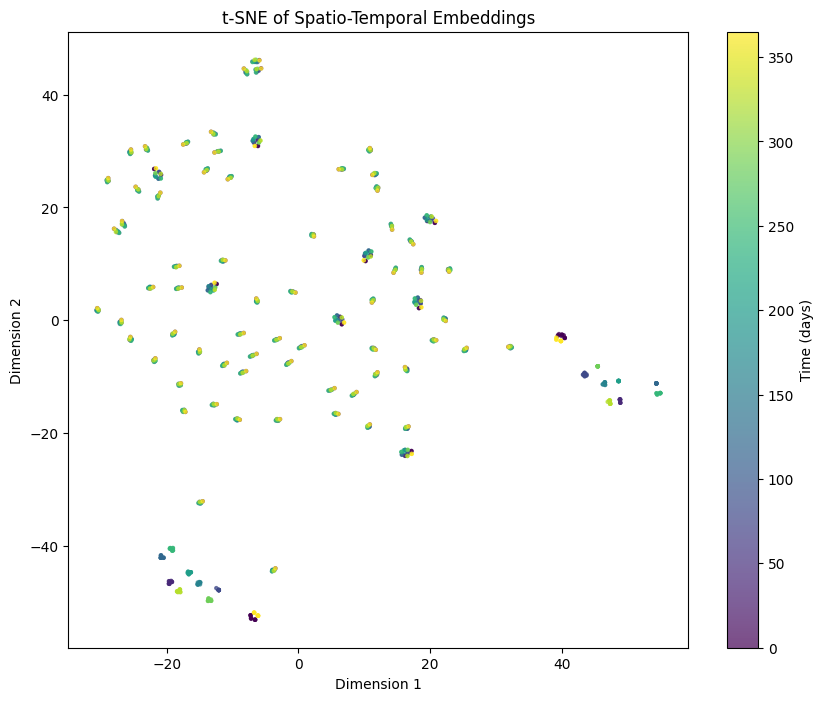

In [21]:
# Time
plt.figure(figsize=(10, 8))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=coords[:, 2], cmap='viridis', s=5, alpha=0.7)
plt.title("t-SNE of Spatio-Temporal Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(label='Time (days)')

cursor = mplcursors.cursor(plt.gca(), hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(
    f"Coord: {coords[sel.index].numpy()}"))

plt.show()

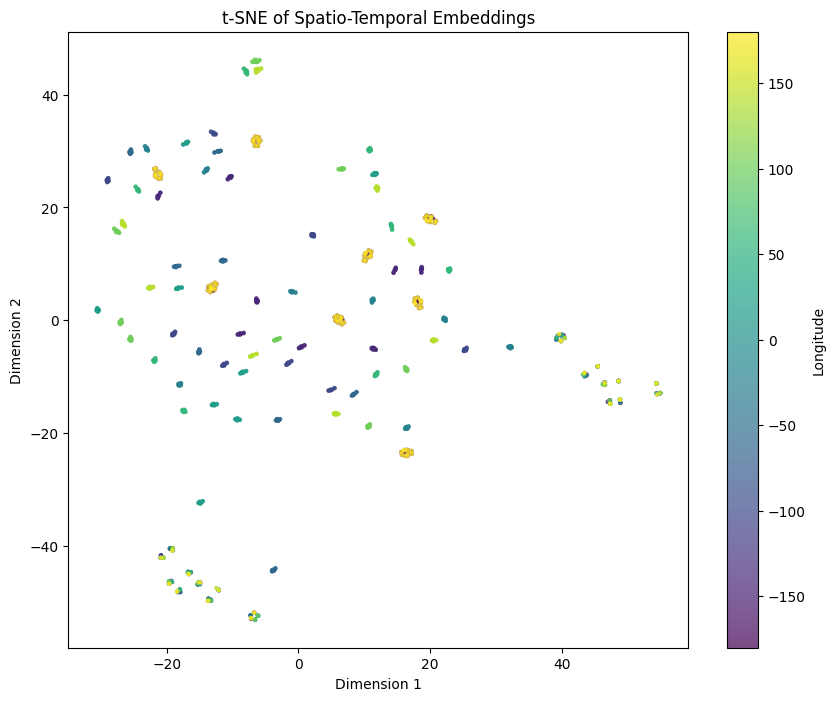

In [22]:
# Longitude
plt.figure(figsize=(10, 8))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=coords[:, 0], cmap='viridis', s=5, alpha=0.7)
plt.title("t-SNE of Spatio-Temporal Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(label='Longitude')

cursor = mplcursors.cursor(plt.gca(), hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(
    f"Coord: {coords[sel.index].numpy()}"))


plt.show()

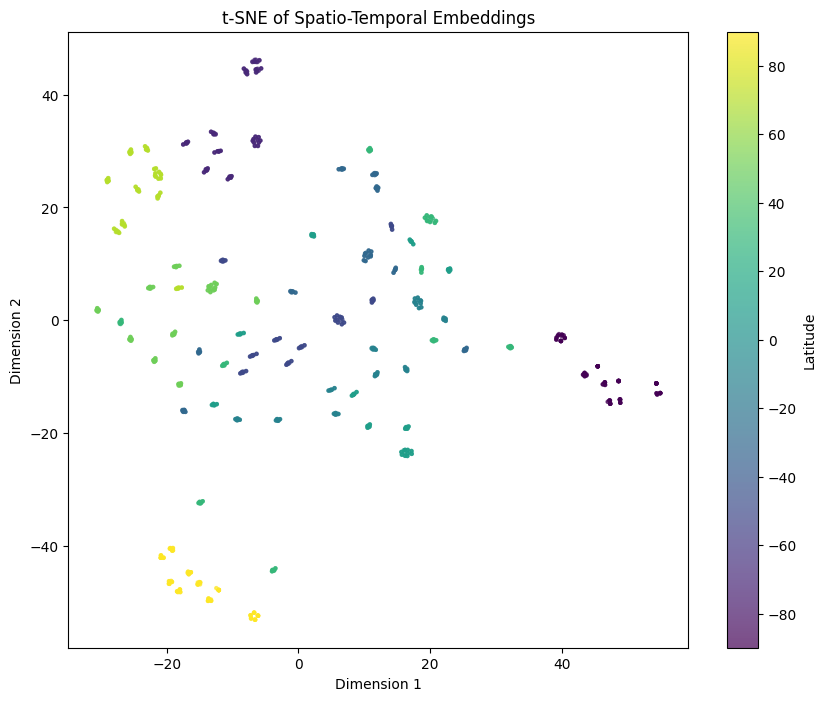

In [23]:
# Latitude
plt.figure(figsize=(10, 8))

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=coords[:, 1], cmap='viridis', s=5, alpha=0.7)
plt.title("t-SNE of Spatio-Temporal Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(label='Latitude')

cursor = mplcursors.cursor(plt.gca(), hover=True)
cursor.connect("add", lambda sel: sel.annotation.set_text(
    f"Coord: {coords[sel.index].numpy()}"))

plt.show()

In [10]:
import rasterio
import numpy as np
import torch
import matplotlib.pyplot as plt
import pathlib
import shapely
import fiona.transform
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

def get_example_image(path, plot=True):
    """
    Loads example Sentinel-2 image from path to tif file
    :param path: Path to image file
    :param plot: If True, will plot an RGB image of the satellite image
    :return: Normalized image as torch tensor
    """
    with rasterio.open(path) as f:
            data = f.read().astype(np.float32)
            image = data / 10000.0
            B10 = np.zeros((1, *image.shape[1:]), dtype=image.dtype)
            image = np.concatenate([image[:10], B10, image[10:]], axis=0)
            image = torch.tensor(image)

            if plot:
                    # Read the first three RGB bands (assuming they are bands 4, 3, and 2)
                    red_band = f.read(4) / 10000.0
                    green_band = f.read(3) / 10000.0
                    blue_band = f.read(2) / 10000.0

                    # Stack the bands to create an RGB image
                    rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

                    # Plot the RGB image
                    plt.imshow(rgb_image)
                    plt.title("RGB Sentinel-2 Image")
                    plt.axis('off')  # Hide axes
                    plt.show()

    return image

def get_metadata(path):
    """
    Loads metadata from a Sentinel-2 image file
    :param path: Path to image file
    :return: Metadata dictionary
    """
    tags = {}

    with rasterio.open(path) as src:
        geom = shapely.geometry.mapping(shapely.geometry.box(*src.bounds))
        warped_geom = fiona.transform.transform_geom(src.crs, "EPSG:4326", geom)
        shape = shapely.geometry.shape(warped_geom)
        x, y = shape.centroid.xy
        x = x[0]
        y = y[0]
        tags = src.tags()
        filename = pathlib.Path(path).name
        t = src.tags().get("datetime")
        id = src.tags().get("granule_id")

    return id, x, y, t, tags

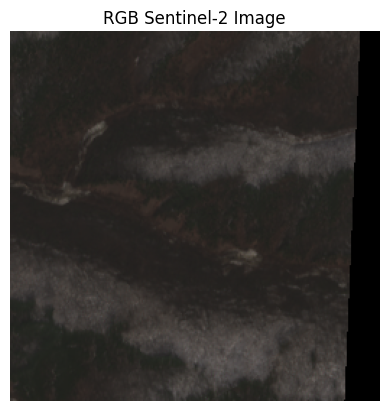

Image ID: S2B_OPER_MSI_L2A_TL_MSFT_20240416T064441_A037138_T50UPC_N05.10, Lon: 120.05444581609738, Lat: 52.210004107821106, Time: 107
Nearest coordinates (lon, lat, time):  [129.86072423  52.79329609 132.72727273]


In [13]:
# Localize an embedding

# Get image from dataset
import datetime

test_img_path = "/home/leca5365/Datasets/satclip-s2-temporal-55k/images/patch_99.tif"

img = get_example_image(test_img_path, plot=True)
id, lon, lat, t, tags = get_metadata(test_img_path)
dt = datetime.datetime.strptime(t, '%Y-%m-%dT%H:%M:%S.%f+00:00')
print(f"Image ID: {id}, Lon: {lon}, Lat: {lat}, Time: {dt.timetuple().tm_yday}")

# Get the visual embedding
import torchvision.transforms as T
cc = T.CenterCrop(224)
img = cc(img)
v_emb = visual_encoder(img.unsqueeze(0).to("cuda:0"))

# Check nearest SpatioTemporal embeddings from the pre-sampled points, and report the corresponding coordinates
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(v_emb.cpu().detach().numpy(), embeddings)
#Get index of control location corresponding to embedding with highest cosine similarity to image embedding
closest = np.argmax(cosine_sim)

print("Nearest coordinates (lon, lat, time): ", coords[closest])
